# Assignment 2 : Language Modeling & Evaluation 

**Student names**: Daniel Høyland <br>
**Group number**: 4 <br>
**Date**: 18 September 2025

## Important notes
Please read and follow these rules. Submissions that do not fulfill them may be returned.
1. You may work in groups of maximum 2 students.
2. Submit in **.ipynb** format only.
3. The assignment must be typed. Handwritten answers are not accepted.

**Due date**: 28.09.2025 23:59

### What you will do
- Build a **unigram document language model** with a **document-term matrix**.
- Rank documents for queries using **Jelinek-Mercer smoothing**.
- Evaluate the run using **Cranfield queries and qrels** (P@k, MAP, MRR).
- (Optional) Try **Dirichlet** and compare briefly.


---
## Dataset

Make sure the Cranfield files are placed next to the notebook:
- `cran.all.1400` — document collection (1400 docs)
- `cran.qry` — queries
- `cranqrel` — relevance judgments (qrels)

> Only the **document parsing** for cran.all.1400 code is provided below. You will implement the rest in the TODO cells.


### Load and parse documents (provided)

Run the cell to parse the Cranfield documents. Update the path so it points to your `cran.all.1400` file.


In [1]:
# TODO: Read 'cran.all.1400' and parse the documents into a suitable data structure

CRAN_PATH = r"cran.all.1400"  # <-- change this!

def parse_cranfield(path):
    docs = {}
    current_id = None
    current_field = None
    buffers = {"T": [], "A": [], "B": [], "W": []}
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.rstrip("\n")
            if line.startswith(".I "):
                if current_id is not None:
                    docs[current_id] = {
                        "id": current_id,
                        "title": " ".join(buffers["T"]).strip(),
                        "abstract": " ".join(buffers["W"]).strip()
                    }
                current_id = int(line.split()[1])
                buffers = {k: [] for k in buffers}
                current_field = None
            elif line.startswith("."):
                tag = line[1:].strip()
                current_field = tag if tag in buffers else None
            else:
                if current_field is not None:
                    buffers[current_field].append(line)
    if current_id is not None:
        docs[current_id] = {
            "id": current_id,
            "title": " ".join(buffers["T"]).strip(),
            "abstract": " ".join(buffers["W"]).strip()
        }
    print(f"Parsed {len(docs)} documents.")
    return docs

docs = parse_cranfield(CRAN_PATH)
print(list(docs.items())[:1])  # peek at the first parsed doc


Parsed 1400 documents.
[(1, {'id': 1, 'title': 'experimental investigation of the aerodynamics of a wing in a slipstream .', 'abstract': 'experimental investigation of the aerodynamics of a wing in a slipstream .   an experimental study of a wing in a propeller slipstream was made in order to determine the spanwise distribution of the lift increase due to slipstream at different angles of attack of the wing and at different free stream to slipstream velocity ratios .  the results were intended in part as an evaluation basis for different theoretical treatments of this problem .   the comparative span loading curves, together with supporting evidence, showed that a substantial part of the lift increment produced by the slipstream was due to a /destalling/ or boundary-layer-control effect .  the integrated remaining lift increment, after subtracting this destalling lift, was found to agree well with a potential flow theory .   an empirical evaluation of the destalling effects was made fo

## 2.1 Language Modeling

You will create a **unigram language model** per document, using a **document-term matrix**, and score queries with **Jelinek-Mercer smoothing**.


### 2.1.1 Preprocessing

Implement a simple tokenizer/normalizer (e.g., lowercasing, punctuation removal and stopword removal) and apply it to each document

- Return a list of tokens for each document.


In [2]:
# TODO: Implement preprocessing and apply to all documents

STOPWORDS = set("""a about above after again against all am an and any are aren't as at be because been
before being below between both but by can't cannot could couldn't did didn't do does doesn't doing don't down
during each few for from further had hadn't has hasn't have haven't having he he'd he'll he's her here here's hers
herself him himself his how how's i i'd i'll i'm i've if in into is isn't it it's its itself let's me more most
mustn't my myself no nor not of off on once only or other ought our ours ourselves out over own same shan't she
she'd she'll she's should shouldn't so some such than that that's the their theirs them themselves then there there's
these they they'd they'll they're they've this those through to too under until up very was wasn't we we'd we'll we're
we've were weren't what what's when when's where where's which while who who's whom why why's with won't would wouldn't
you you'd you'll you're you've your yours yourself yourselves""".split())

# Your code here
tokenized_docs = {}

for doc_id, doc in docs.items():
    # COmbining the title and abstract
    text = (doc["title"] + " " + doc["abstract"]).lower()

    # Keeping letters and spaces
    cleanedText = ""
    for ch in text:
        if ch.isalpha() or ch.isspace():
            cleanedText += ch
        else:
            cleanedText += " "
            
    #Splitting into words based on spaces 
    tokens = cleanedText.split()

    # Removing the stopwords
    filtered = [t for t in tokens if t not in STOPWORDS]

    #Storing the tokenized words back into variables
    tokenized_docs[doc_id] = filtered
    docs[doc_id]["tokens"] = filtered
    
#Testing to see if it works
print(f"Tokenized {len(tokenized_docs)} documents.")
print(docs[1]["tokens"])  

Tokenized 1400 documents.
['experimental', 'investigation', 'aerodynamics', 'wing', 'slipstream', 'experimental', 'investigation', 'aerodynamics', 'wing', 'slipstream', 'experimental', 'study', 'wing', 'propeller', 'slipstream', 'made', 'order', 'determine', 'spanwise', 'distribution', 'lift', 'increase', 'due', 'slipstream', 'different', 'angles', 'attack', 'wing', 'different', 'free', 'stream', 'slipstream', 'velocity', 'ratios', 'results', 'intended', 'part', 'evaluation', 'basis', 'different', 'theoretical', 'treatments', 'problem', 'comparative', 'span', 'loading', 'curves', 'together', 'supporting', 'evidence', 'showed', 'substantial', 'part', 'lift', 'increment', 'produced', 'slipstream', 'due', 'destalling', 'boundary', 'layer', 'control', 'effect', 'integrated', 'remaining', 'lift', 'increment', 'subtracting', 'destalling', 'lift', 'found', 'agree', 'well', 'potential', 'flow', 'theory', 'empirical', 'evaluation', 'destalling', 'effects', 'made', 'specific', 'configuration', '

### 2.1.2 Build the matrix

Construct:
- A vocabulary `term -> column_index`
- A (sparse) **document–term count matrix**
- Document lengths `|d|` and collection (all documents) totals

> Tip: You may use dictionaries or `scipy.sparse` for efficiency.


In [3]:
# TODO: Build vocabulary, doc-term counts (sparse), document lengths, and collection totals
# Your code here
from scipy.sparse import lil_matrix
vocab = {}
for doc in tokenized_docs.values():
    for token in doc:
        if token not in vocab:
            vocab[token] = len(vocab)

num_docs = len(tokenized_docs)
num_terms = len(vocab)

dt_matrix = lil_matrix((num_docs, num_terms), dtype=int)  # sparse doc-term matrix
doc_lengths = [0] * num_docs                             # |d| per doc
collection_counts = {}                                   # total term frequencies


# fill matrix
for doc_id, tokens in tokenized_docs.items():
    row = doc_id - 1 
    counts = {}
    for tok in tokens:
        counts[tok] = counts.get(tok, 0) + 1
    
    for term, freq in counts.items():
        col = vocab[term]
        dt_matrix[row, col] = freq
        collection_counts[term] = collection_counts.get(term, 0) + freq

    doc_lengths[row] = sum(counts.values())

collection_length = sum(doc_lengths)

print("Vocabulary size:", len(vocab))
print("Matrix shape:", dt_matrix.shape)
print("First doc length:", doc_lengths[0])
print("Collection length:", collection_length)



Vocabulary size: 6934
Matrix shape: (1400, 6934)
First doc length: 84
Collection length: 141060


### 2.1.3 Rank with **Jelinek-Mercer smoothing**

Implement query likelihood scoring with Jelinek-Mercer smoothing:

$\hat{P}(t \mid M_d) = \lambda \hat{P}_{\text{mle}}(t \mid M_d) + (1 - \lambda)\hat{P}_{\text{mle}}(t \mid M_c), \ \lambda = 0.5$



In [4]:
""" TODO: Create a function for implementing query likelihood scoring with Jelinek Mercer smoothing (λ=0.5), 
using the formula above."""

import math
def jelinek_smoothing(query: str, topk=None):
    lam = 0.5 
    
    query = query.lower()
    cleaned = "".join(ch if ch.isalpha() or ch.isspace() else " " for ch in query)
    q_tokens = [t for t in cleaned.split() if t not in STOPWORDS]
    scores = []
    for doc_id in range(1, num_docs + 1):
        row = doc_id - 1
        doc_len = doc_lengths[row]
        score = 0.0
        for t in q_tokens:
            p_c = collection_counts.get(t, 0) / collection_length
            if t in vocab:
                f_td = dt_matrix[row, vocab[t]]
                p_d = f_td / doc_len if doc_len > 0 else 0.0
            else:
                p_d = 0.0
            p = lam * p_d + (1 - lam) * p_c
            if p > 0:
                score += math.log(p)
        scores.append((doc_id, score))
    scores.sort(key=lambda x: x[1], reverse=True)
    if topk is None:
        return scores
    return scores[:topk]


In [5]:
# Do not change this code
queries_assignment2 = [
  "gas pressure",
  "structural aeroelastic flight high speed aircraft",
  "heat conduction composite slabs",
  "boundary layer control",
  "compressible flow nozzle",
  "combustion chamber injection",
  "laminar turbulent transition",
  "fatigue crack growth",
  "wing tip vortices",
  "propulsion efficiency"
]

In [6]:
# Run Jelinek-Mercer smoothing on queries in batch (print top-10 results for each), using the function you created
def run_batch_smoothing(queries):
    results = {}
    for i, q in enumerate(queries, 1):
        res = jelinek_smoothing(q)
        results[f"Q{i}"] = res
    return results

jelinek_results = run_batch_smoothing(queries_assignment2)

for qid, res in jelinek_results.items():
    print(qid, "=>", res[:10])


Q1 => [(169, -7.358774921108503), (183, -7.665046129019961), (1003, -7.709730473083853), (1312, -7.844988615101439), (1143, -7.905145193996516), (1315, -7.946965278287296), (975, -8.005536414247773), (1274, -8.012091630580457), (1319, -8.068235547021228), (1139, -8.11251759989598)]
Q2 => [(12, -22.82455210793124), (141, -32.57131245146435), (746, -32.73984499694139), (51, -34.81759754772649), (875, -35.27236656615204), (1169, -35.78264125759373), (1170, -35.79919997916861), (884, -36.07767907663578), (14, -36.08531423479188), (1263, -36.61278351846516)]
Q3 => [(399, -13.581023893004552), (5, -15.621881287329584), (144, -19.414332612693308), (485, -20.369971624296962), (181, -20.912077233796296), (542, -22.99415016809639), (582, -25.49018320477475), (1073, -26.574585882545612), (119, -26.878393790329376), (91, -27.140624969373278)]
Q4 => [(265, -11.603225015895074), (1205, -12.06000087875682), (1288, -13.026985356735501), (416, -13.294223214557151), (3, -13.396414567820827), (974, -13.4

#### Dirichlet

If you have time, also implement Dirichlet smoothing and briefly compare the top-10 lists for the first query in the queries_assignment2 list


In [7]:
# TODO (Optional): Implement Dirichlet scoring and compare with Jelinek-Mercer
# Your code here
def dirichlet_smoothing(query: str):
    mu: int = 1500
    topk: int = 10
    query = query.lower()
    cleaned = "".join(ch if ch.isalpha() or ch.isspace() else " " for ch in query)
    q_tokens = [t for t in cleaned.split() if t not in STOPWORDS]

    scores = []

    for doc_id in range(1, num_docs + 1):
        row = doc_id - 1
        doc_len = doc_lengths[row]
        score = 0.0

        for t in q_tokens:
            f_td = 0
            if t in vocab:
                f_td = dt_matrix[row, vocab[t]]

            p_c = collection_counts.get(t, 0) / collection_length

            # Dirichlet smoothing
            p = (f_td + mu * p_c) / (doc_len + mu)

            if p > 0:
                score += math.log(p)

        scores.append((doc_id, score))

    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:topk]


In [8]:
first_query = queries_assignment2[0]

jm_results = jelinek_smoothing(first_query)
dirichlet_results = dirichlet_smoothing(first_query)

print("Jelinek-Mercer (λ=0.5):", jm_results[:10])
print("Dirichlet (μ=1500):", dirichlet_results[:10])


Jelinek-Mercer (λ=0.5): [(169, -7.358774921108503), (183, -7.665046129019961), (1003, -7.709730473083853), (1312, -7.844988615101439), (1143, -7.905145193996516), (1315, -7.946965278287296), (975, -8.005536414247773), (1274, -8.012091630580457), (1319, -8.068235547021228), (1139, -8.11251759989598)]
Dirichlet (μ=1500): [(185, -9.558400867885808), (169, -9.726360050835089), (1274, -9.804451178474874), (1319, -9.810513626281441), (166, -9.821666961679064), (1286, -9.851027731288937), (1003, -9.85206462759531), (110, -9.864345793808992), (493, -9.87264804090658), (975, -9.874564864904501)]


## 2.2 Evaluation (Cranfield queries + qrels)

Evaluate your retrieval system using **Cranfield**:
- Parse **queries** from `cran.qry`
- Parse **relevance judgments** from `cranqrel`
- Compute **P@k (k=5,10)**, **MAP (Mean Average Precision)**, and **MRR (Mean Reciprocal Rank)** over all queries


### 2.2.1 Parse `cran.qry` and `cranqrel`

- Create `queries[qid] = "text"` by parsing `cran.qry`
- Create `qrels[qid] = set(relevant_doc_ids)` by parsing `cranqrel`


In [9]:
# TODO: Parse cran.qry and cranqrel into convenient data structures
# Your code here
CRAN_QRY = "cran.qry"
CRAN_QREL = "cranqrel"

queries = {}
current_id = None
current_field = None
buffer = []

with open(CRAN_QRY, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        line = line.rstrip("\n")
        if line.startswith(".I "):
            if current_id is not None:
                queries[current_id] = " ".join(buffer).strip()
            current_id = int(line.split()[1])
            buffer = []
            current_field = None
        elif line.startswith(".W"):
            current_field = "W"
        else:
            if current_field == "W":
                buffer.append(line)
    # last query
    if current_id is not None:
        queries[current_id] = " ".join(buffer).strip()

print(f"Parsed {len(queries)} queries.")

qrels = {}

with open(CRAN_QREL, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        parts = line.split()
        if len(parts) >= 3:
            qid = int(parts[0])
            docid = int(parts[2])
            if qid not in qrels:
                qrels[qid] = set()
            qrels[qid].add(docid)

print(f"Parsed relevance judgments for {len(qrels)} queries.")


Parsed 225 queries.
Parsed relevance judgments for 225 queries.


### 2.2.2 Implement metrics: P@k, MAP, MRR

Write functions to compute:
- Precision@k (for **k=5** and **k=10**)
- Mean Average Precision (MAP)
- Mean Reciprocal Rank (MRR)


In [10]:
# TODO: Implement P@k (k=5,10), MAP, and MRR
# Your code here
def evaluate(all_ranked, all_qrels, ks=(5, 10)):


    prec_sums = {k: 0.0 for k in ks}
    ap_sum = 0.0
    rr_sum = 0.0
    n_queries = 0

    for qid, ranked_list in all_ranked.items():
        if qid not in all_qrels:
            continue
        relevant_docs = all_qrels[qid]
        n_queries += 1

        # Precision@k
        for k in ks:
            topk = ranked_list[:k]
            num_rel = sum(1 for doc in topk if doc in relevant_docs)
            prec_sums[k] += num_rel / k

        # Average Precision
        num_rel = 0
        ap_score = 0.0
        for i, doc_id in enumerate(ranked_list, start=1):
            if doc_id in relevant_docs:
                num_rel += 1
                ap_score += num_rel / i
        if relevant_docs:
            ap_sum += ap_score / len(relevant_docs)

        # Reciprocal Rank
        rr = 0.0
        for i, doc_id in enumerate(ranked_list, start=1):
            if doc_id in relevant_docs:
                rr = 1 / i
                break
        rr_sum += rr

    
    results = {f"P@{k}": prec_sums[k] / n_queries for k in ks}
    results["MAP"] = ap_sum / n_queries if n_queries > 0 else 0.0
    results["MRR"] = rr_sum / n_queries if n_queries > 0 else 0.0

    return results


### 2.2.3 Evaluate your run

- For **all queries**, generate rankings with your **Jelinek-Mercer** model
- Report aggregate metrics: P@5, P@10, MAP, MRR


In [11]:
# TODO: Run retrieval for all queries and compute P@5, P@10, MAP, and MRR
# Your code here
all_ranked = {}

for qid, query_text in queries.items():
    res = jelinek_smoothing(query_text)  
    ranked_docs = [doc_id for doc_id, score in res]
    all_ranked[qid] = ranked_docs

metrics = evaluate(all_ranked, qrels, ks=(5, 10))
print(metrics)


{'P@5': 0.006578947368421052, 'P@10': 0.006578947368421052, 'MAP': 0.01153974245881806, 'MRR': 0.024021460766446758}



### 2.2.4 Interpolated precision–recall curves (11‑point)

- For **all queries**, if you don’t have query IDs, assign sequential IDs: `Q1, Q2, ..., Qm` in the order they appear.
- Using your **rankings from task 2.2.3** and the **relevance judgments (`cranqrel`)**, compute **precision** and **recall** at each rank for each query.
- For the 11 standard recall levels `R = {0.0, 0.1, ..., 1.0}`, compute the **interpolated precision** at level `r` as the **maximum precision** observed at any point with recall ≥ `r`.
- **Report/plot** the **11‑point interpolated precision–recall curve** across queries (and optionally a few per‑query curves).

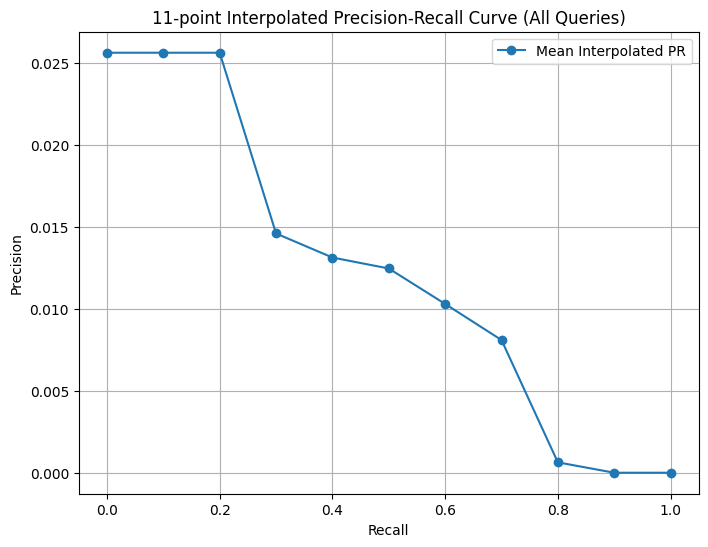

In [13]:
# TODO: Compute the 11-point interpolated precision–recall for each query

# Your code here
import matplotlib.pyplot as plt

recall_levels = [i / 10 for i in range(11)]
interp_all = []

for qid, ranked_docs in all_ranked.items():
    relevant_docs = qrels.get(qid, set())
    total_rel = len(relevant_docs)
    if total_rel == 0:
        continue

    precisions = []
    recalls = []
    num_rel = 0
    
    for i, doc_id in enumerate(ranked_docs, start=1):
        if doc_id in relevant_docs:
            num_rel += 1
        precision = num_rel / i
        recall = num_rel / total_rel
        precisions.append(precision)
        recalls.append(recall)
    
    interp_prec = []
    for r in recall_levels:
        p = max((p for p, rc in zip(precisions, recalls) if rc >= r), default=0.0)
        interp_prec.append(p)
    
    interp_all.append(interp_prec)

avg_interp = [sum(col) / len(interp_all) for col in zip(*interp_all)]

plt.figure(figsize=(8,6))
plt.plot(recall_levels, avg_interp, marker='o', label="Mean Interpolated PR")
plt.title("11-point Interpolated Precision-Recall Curve (All Queries)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.legend()
plt.show()
